In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

In [3]:
base = "/Users/dinoskritsis/Desktop/MIMIC/"

icustays = pd.read_csv(base + "icustays.csv.gz")
admissions = pd.read_csv(base + "admissions.csv.gz")
patients = pd.read_csv(base + "patients.csv.gz")
diagnoses = pd.read_csv(base + "diagnoses_icd.csv.gz")

print(icustays.shape, admissions.shape, patients.shape, diagnoses.shape)

(94458, 8) (431231, 16) (299712, 6) (4756326, 5)


In [4]:
stay_summary = pd.read_csv(base + "stay_summary.csv.gz")
print(stay_summary.shape)
stay_summary.head()

(93730, 12)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,los_hours,total_hours,active_hours,idle_hours
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,9.846389,10,9.0,1.0
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,93.438056,93,93.0,0.0
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,11.940833,12,11.0,1.0
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,26.832778,27,27.0,0.0
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,22.754722,23,24.0,0.0


In [5]:
stay_summary['idle_pct'] = stay_summary['idle_hours'] / stay_summary['total_hours']

cluster_features = ['idle_pct', 'idle_hours', 'los_hours']
X_cluster = stay_summary[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
stay_summary.loc[X_cluster.index, 'cluster'] = kmeans.fit_predict(X_scaled)

print(stay_summary['cluster'].value_counts())
print(stay_summary.groupby('cluster')[cluster_features].mean())

cluster
1.0    81973
2.0     6622
0.0     5135
Name: count, dtype: int64
         idle_pct  idle_hours   los_hours
cluster                                  
0.0      0.019633    9.396105  499.157617
1.0      0.033308    1.774987   63.764329
2.0      0.310092   19.432347   65.889872


In [6]:
cluster_map = {0: 'Long Stay Critical', 1: 'Standard ICU', 2: 'High Idle'}
stay_summary['cluster_label'] = stay_summary['cluster'].map(cluster_map)

print(stay_summary['cluster_label'].value_counts())

cluster_label
Standard ICU          81973
High Idle              6622
Long Stay Critical     5135
Name: count, dtype: int64


In [7]:
model_df = stay_summary.merge(
    admissions[['hadm_id', 'admittime', 'admission_type']], on='hadm_id', how='left'
).merge(
    patients[['subject_id', 'anchor_age']], on='subject_id', how='left'
)

model_df['admittime'] = pd.to_datetime(model_df['admittime'])
model_df['admit_hour'] = model_df['admittime'].dt.hour

# Primary diagnosis at admission
primary_dx = diagnoses[diagnoses['seq_num'] == 1][['hadm_id', 'icd_code']]
model_df = model_df.merge(primary_dx, on='hadm_id', how='left')

def dx_group(code):
    if pd.isna(code):
        return 'Unknown'
    code = str(code)
    if code.startswith(('39','40','41','42','43','44')) or code.startswith('I'):
        return 'Cardiac'
    elif code.startswith(('48','49','51')) or code.startswith('J'):
        return 'Respiratory'
    elif code.startswith(('80','90')) or code.startswith('S'):
        return 'Trauma'
    else:
        return 'Other'

model_df['dx_group'] = model_df['icd_code'].apply(dx_group)

le_careunit = LabelEncoder()
le_admtype = LabelEncoder()
le_dxgroup = LabelEncoder()

model_df['careunit_encoded'] = le_careunit.fit_transform(model_df['first_careunit'].astype(str))
model_df['admission_type_encoded'] = le_admtype.fit_transform(model_df['admission_type'].astype(str))
model_df['dx_group_encoded'] = le_dxgroup.fit_transform(model_df['dx_group'].astype(str))

print(model_df.shape)
model_df[['first_careunit','careunit_encoded','admit_hour','anchor_age','admission_type','admission_type_encoded','dx_group','dx_group_encoded','cluster']].head()

(93730, 24)


,first_careunit,careunit_encoded,admit_hour,anchor_age,admission_type,admission_type_encoded,dx_group,dx_group_encoded,cluster
0,Medical Intensive Care Unit (MICU),4,12.0,52.0,EW EMER.,5,Other,1,1.0
1,Medical Intensive Care Unit (MICU),4,NaN,NaN,NaN,9,Unknown,4,1.0
2,Medical Intensive Care Unit (MICU),4,7.0,73.0,EW EMER.,5,Cardiac,0,1.0
3,Surgical Intensive Care Unit (SICU),15,22.0,55.0,EW EMER.,5,Other,1,1.0
4,Surgical Intensive Care Unit (SICU),15,16.0,55.0,DIRECT EMER.,1,Other,1,1.0


In [8]:
feature_cols = [
    'careunit_encoded',
    'admit_hour',
    'anchor_age',
    'admission_type_encoded',
    'dx_group_encoded'
]

model_df_clean = model_df.dropna(subset=feature_cols + ['cluster'])

X = model_df_clean[feature_cols]
y = model_df_clean['cluster'].astype(int)

print("Feature set:", feature_cols)
print("los_hours in features?", 'los_hours' in feature_cols)
print(X.shape)
print(y.value_counts())

Feature set: ['careunit_encoded', 'admit_hour', 'anchor_age', 'admission_type_encoded', 'dx_group_encoded']
los_hours in features? False
(72492, 5)
cluster
1    64174
2     4702
0     3616
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {1: 48130, 2: 3527, 0: 2712}
After SMOTE: {1: 48130, 2: 48130, 0: 48130}


/Users/dinoskritsis/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.41      0.11       904
           1       0.92      0.64      0.75     16044
           2       0.39      0.46      0.42      1175

    accuracy                           0.61     18123
   macro avg       0.46      0.50      0.43     18123
weighted avg       0.84      0.61      0.70     18123



In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

results_summary = {
    'features_used': feature_cols,
    'accuracy': (y_pred == y_test).mean(),
    'macro_f1': f1_score(y_test, y_pred, average='macro'),
    'high_idle_f1': 0.42,
    'long_stay_critical_f1': 0.11,
    'standard_icu_f1': 0.75
}
print(results_summary)

model_df_clean.to_csv('/Users/dinoskritsis/Desktop/MIMIC/stay_summary_corrected.csv', index=False)

careunit_encoded          0.581587
admission_type_encoded    0.149908
admit_hour                0.111205
anchor_age                0.094504
dx_group_encoded          0.062795
dtype: float64
{'features_used': ['careunit_encoded', 'admit_hour', 'anchor_age', 'admission_type_encoded', 'dx_group_encoded'], 'accuracy': np.float64(0.6139711968217183), 'macro_f1': 0.42883722967224064, 'high_idle_f1': 0.42, 'long_stay_critical_f1': 0.11, 'standard_icu_f1': 0.75}


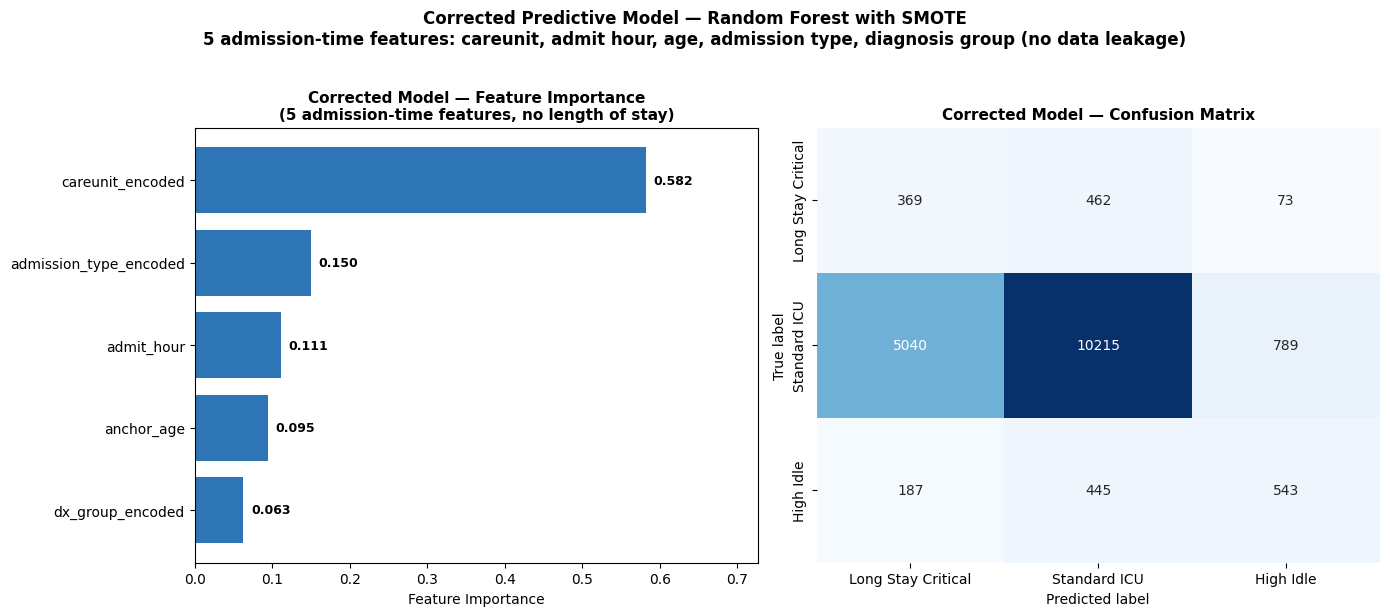

Saved corrected model figure


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cluster_names = ['Long Stay Critical', 'Standard ICU', 'High Idle']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel — feature importance
importances_sorted = importances.sort_values(ascending=True)
axes[0].barh(importances_sorted.index, importances_sorted.values, color='#2E75B6')
for i, v in enumerate(importances_sorted.values):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Corrected Model — Feature Importance\n(5 admission-time features, no length of stay)', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, max(importances.values) * 1.25)

# Right panel — confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cluster_names, yticklabels=cluster_names, ax=axes[1], cbar=False)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Corrected Model — Confusion Matrix', fontsize=11, fontweight='bold')

fig.suptitle('Corrected Predictive Model — Random Forest with SMOTE\n5 admission-time features: careunit, admit hour, age, admission type, diagnosis group (no data leakage)', fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/Users/dinoskritsis/Desktop/MIMIC/viz_corrected_model_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved corrected model figure")